In [ ]:
%cd ..

In [ ]:
import torch
import pandas as pd
import numpy as np
import random
import os

In [ ]:
def set_seed(seed=42):
    # 1. Basic Python and NumPy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU

    # 3. Force CuDNN to be deterministic (Note: this can slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
df = pd.read_csv('/data/no_beta_engineered_data.csv')

In [ ]:
df = df.drop(columns='Unnamed: 0')
df = df.dropna()

In [ ]:
df

,no_show,APPT_WEEKDAY,APPT_DAY_PART,DURATION,BOOK_TO_APPT,APPT_SEQ,CANCELS_365,APPTS_365,NOSHOWS_365,RESCHEDS_365,...,c5_SE_stt,c5_COI_stt,r_ED_stt,r_HE_stt,r_SE_stt,r_COI_stt,indv_noshow_no,indv_noshow_yes,group_show_count,group_noshow_count
0,Yes,Wednesday,Evening,270,9,Unknown,0,3,2,0,...,Moderate,Moderate,54.0,39.0,44.0,46.0,55.0,7.0,11038,2047
1,No,Tuesday,Afternoon,30,76,Unknown,2,4,0,0,...,Moderate,Moderate,25.0,22.0,54.0,43.0,61.0,11.0,15914,1483
2,No,Thursday,Evening,270,10,Unknown,0,8,0,0,...,Very High,Very High,74.0,47.0,94.0,84.0,7.0,2.0,11038,2047
3,No,Wednesday,Morning,60,321,Unknown,0,8,0,0,...,Low,Low,29.0,23.0,26.0,25.0,27.0,0.0,11038,2047
4,No,Monday,Afternoon,15,368,Unknown,0,2,0,1,...,High,Very High,94.0,68.0,78.0,86.0,7.0,2.0,15914,1483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459380,No,Thursday,Morning,20,0,Unknown,1,3,0,1,...,Very High,Very High,92.0,51.0,98.0,95.0,22.0,1.0,15914,1483
459381,Yes,Thursday,Afternoon,15,0,Unknown,1,3,1,1,...,High,High,80.0,54.0,69.0,73.0,66.0,10.0,15914,1483
459382,Yes,Thursday,Afternoon,30,0,Unknown,1,36,3,11,...,Moderate,High,96.0,44.0,55.0,74.0,95.0,18.0,11038,2047
459383,No,Wednesday,Afternoon,5,0,Unknown,9,51,5,13,...,Low,Low,15.0,40.0,39.0,32.0,76.0,7.0,11038,2047


In [ ]:
targets = torch.tensor((df['no_show'] == 'Yes').values).float()

In [ ]:
targets

tensor([1., 0., 0.,  ..., 1., 0., 0.])

In [ ]:
sum(targets)

tensor(56301.)

In [ ]:
X = df.drop(columns='no_show')

In [ ]:
X_processed = pd.get_dummies(X, drop_first=True)

In [ ]:
inputs = torch.tensor(X_processed.astype(float).values).float()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Convert PyTorch tensors to NumPy arrays for scikit-learn and XGBoost
X_data = inputs.cpu().numpy()
y_data = targets.cpu().numpy()

# Perform a train-test split for hyperparameter tuning.
# GridSearchCV will perform its own internal cross-validation on X_tune_train, y_tune_train.
X_tune_train, X_tune_test, y_tune_train, y_tune_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

print(f"Shape of X_tune_train: {X_tune_train.shape}")
print(f"Shape of y_tune_train: {y_tune_train.shape}")

Shape of X_tune_train: (359812, 215)
Shape of y_tune_train: (359812,)


In [ ]:
# Define the XGBoost classifier
# use_label_encoder=False to suppress a deprecation warning
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50,100,150], # Number of boosting rounds
    'max_depth': [3, 7, 11, 13, 15, 19],       # Maximum depth of a tree
    'learning_rate': [0.14, 0.45, 0.76, 1.37, 1.78] # Step size shrinkage to prevent overfitting
}

# Define scoring metrics. We need to use make_scorer for custom metrics with GridSearchCV.
scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Set up cross-validation strategy. StratifiedKFold is suitable for imbalanced datasets.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
# Initialize GridSearchCV
# Refit='recall' means the best model will be chosen based on the highest recall score.
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    refit='f1', # Optimize for recall given the context of previous low recall scores
    verbose=2, # Set to 2 to see more details during the search
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_tune_train, y_tune_train)
print("GridSearchCV finished.")

Starting GridSearchCV...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:11:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV finished.


In [ ]:
print("Best parameters found: ", grid_search.best_params_)
print("Best recall score found during CV: {:.4f}".format(grid_search.best_score_))

# Evaluate the best model found by GridSearchCV on the hold-out test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_tune_test)

final_precision = precision_score(y_tune_test, y_pred)
final_recall = recall_score(y_tune_test, y_pred)
final_f1 = f1_score(y_tune_test, y_pred)

print(f"Precision on test set with best model: {final_precision:.4f}")
print(f"Recall on test set with best model: {final_recall:.4f}")
print(f"F1-score on test set with best model: {final_f1:.4f}")

Best parameters found:  {'learning_rate': 1.78, 'max_depth': 11, 'n_estimators': 150}
Best recall score found during CV: 0.2177
Precision on test set with best model: 0.2324
Recall on test set with best model: 0.1717
F1-score on test set with best model: 0.1975


In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Find the index of the row with the maximum mean_test_recall
best_recall_index = results_df['mean_test_recall'].idxmax()

# Get the parameters for the model with the highest recall
best_recall_params = results_df.loc[best_recall_index][['param_n_estimators', 'param_max_depth', 'param_learning_rate']]
best_recall_score = results_df.loc[best_recall_index]['mean_test_recall']

print("Model with the highest recall:")
print(best_recall_params)
print(f"Highest recall score: {best_recall_score:.4f}")

Model with the highest recall:
param_n_estimators      150
param_max_depth          11
param_learning_rate    1.78
Name: 80, dtype: object
Highest recall score: 0.2207


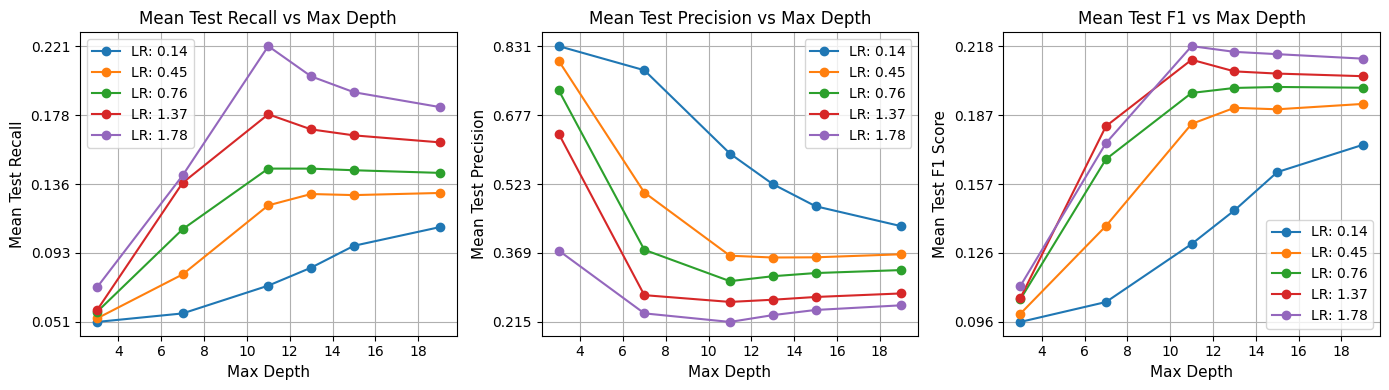

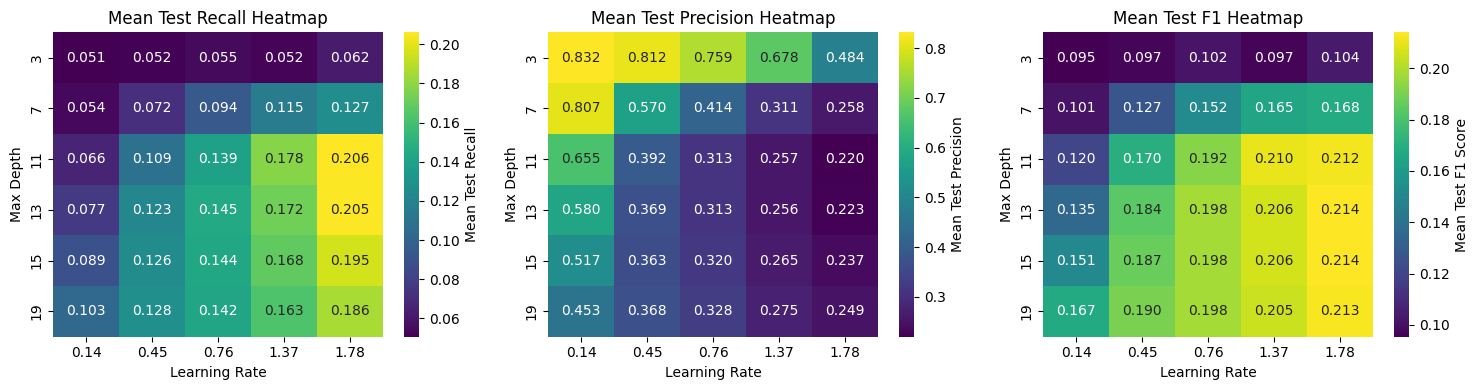

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Plotting evaluation metrics from GridSearchCV results
results = grid_search.cv_results_
results_df = pd.DataFrame(results)

# Filter out learning_rate 1.89 from the entire results_df for consistent plotting
results_df = results_df[results_df['param_learning_rate'] != 1.89].copy()

# Get the best n_estimators from the search
best_n_estimators = grid_search.best_params_['n_estimators']

# Filter results to analyze impact of max_depth and learning_rate for the best n_estimators
results_df_filtered = results_df[results_df['param_n_estimators'] == best_n_estimators]

plt.figure(figsize=(14, 4)) # Increased figure size for 3 plots
title_size = 12
axis_size = 11
# Plot Mean Test Recall vs Max Depth for different Learning Rates
plt.subplot(1, 3, 1) # Changed to 1, 3, 1
for lr in sorted(results_df_filtered['param_learning_rate'].unique()):
    subset = results_df_filtered[results_df_filtered['param_learning_rate'] == lr]
    plt.plot(subset['param_max_depth'], subset['mean_test_recall'], marker='o', label=f'LR: {lr}')
plt.title(f'Mean Test Recall vs Max Depth',fontdict={'size':title_size})
plt.xlabel('Max Depth',fontdict={'size':axis_size})
plt.ylabel('Mean Test Recall',fontdict={'size':axis_size})
plt.legend()
plt.grid(True)
min_recall = results_df_filtered['mean_test_recall'].min()
max_recall = results_df_filtered['mean_test_recall'].max()
plt.yticks(np.linspace(min_recall, max_recall, 5))
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Plot Mean Test Precision vs Max Depth for different Learning Rates
plt.subplot(1, 3, 2) # Changed to 1, 3, 2
for lr in sorted(results_df_filtered['param_learning_rate'].unique()):
    subset = results_df_filtered[results_df_filtered['param_learning_rate'] == lr]
    plt.plot(subset['param_max_depth'], subset['mean_test_precision'], marker='o', label=f'LR: {lr}')
plt.title(f'Mean Test Precision vs Max Depth',fontdict={'size':title_size})
plt.xlabel('Max Depth',fontdict={'size':axis_size})
plt.ylabel('Mean Test Precision',fontdict={'size':axis_size})
plt.legend()
plt.grid(True)
min_precision = results_df_filtered['mean_test_precision'].min()
max_precision = results_df_filtered['mean_test_precision'].max()
plt.yticks(np.linspace(min_precision, max_precision, 5))
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Plot Mean Test F1 vs Max Depth for different Learning Rates
plt.subplot(1, 3, 3) # Changed to 1, 3, 3 for F1 score
for lr in sorted(results_df_filtered['param_learning_rate'].unique()):
    subset = results_df_filtered[results_df_filtered['param_learning_rate'] == lr]
    plt.plot(subset['param_max_depth'], subset['mean_test_f1'], marker='o', label=f'LR: {lr}')
plt.title(f'Mean Test F1 vs Max Depth',fontdict={'size':title_size})
plt.xlabel('Max Depth',fontdict={'size':axis_size})
plt.ylabel('Mean Test F1 Score',fontdict={'size':axis_size})
plt.legend()
plt.grid(True)
min_f1 = results_df_filtered['mean_test_f1'].min()
max_f1 = results_df_filtered['mean_test_f1'].max()
plt.yticks(np.linspace(min_f1, max_f1, 5))
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.show()

# Create heatmaps to visualize the interaction between max_depth and learning_rate
# for mean test recall, precision, and TP/FP Ratio across all n_estimators for simplicity.
# If n_estimators interaction is also important, more plots would be needed.
pivot_table_recall = results_df.pivot_table(index='param_max_depth', columns='param_learning_rate', values='mean_test_recall')
pivot_table_precision = results_df.pivot_table(index='param_max_depth', columns='param_learning_rate', values='mean_test_precision')
pivot_table_f1 = results_df.pivot_table(index='param_max_depth', columns='param_learning_rate', values='mean_test_f1') # Changed to mean_test_f1

plt.figure(figsize=(15, 4)) # Increased figure size for 3 plots

plt.subplot(1, 3, 1) # Changed to 1, 3, 1
sns.heatmap(pivot_table_recall, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'Mean Test Recall'})
plt.title(f'Mean Test Recall Heatmap')
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')

plt.subplot(1, 3, 2) # Changed to 1, 3, 2
sns.heatmap(pivot_table_precision, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'Mean Test Precision'})
plt.title(f'Mean Test Precision Heatmap')
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')

plt.subplot(1, 3, 3) # Added new heatmap for f1
sns.heatmap(pivot_table_f1, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'Mean Test F1 Score'})
plt.title(f'Mean Test F1 Heatmap') # Updated title
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')

plt.tight_layout()
plt.show()

Training XGBoost model with best recall parameters...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:24:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete.


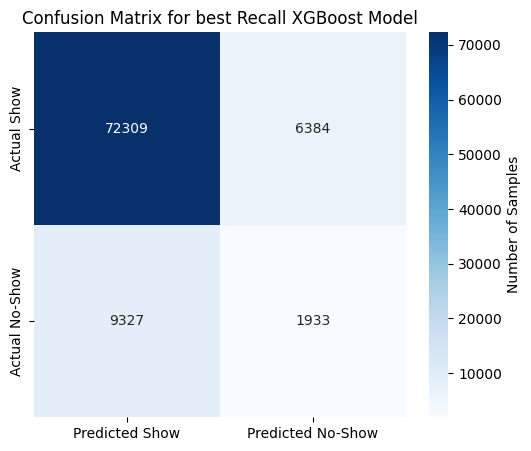

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score
import xgboost as xgb

# 1. Retrieve the best parameters for recall
best_n_estimators_recall = int(best_recall_params['param_n_estimators'])
best_max_depth_recall = int(best_recall_params['param_max_depth'])
best_learning_rate_recall = float(best_recall_params['param_learning_rate'])

# 2. Instantiate and train a new XGBoost model with these parameters
best_recall_xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=best_n_estimators_recall,
    max_depth=best_max_depth_recall,
    learning_rate=best_learning_rate_recall
)

print("Training XGBoost model with best recall parameters...")
best_recall_xgb_model.fit(X_tune_train, y_tune_train)
print("Training complete.")

# 3. Make predictions on the test set using this model
y_pred_recall_model = best_recall_xgb_model.predict(X_tune_test)

# 4. Compute the confusion matrix
cm_recall_model = confusion_matrix(y_tune_test, y_pred_recall_model)

# 5. Visualize the confusion matrix
plt.figure(figsize=(6, 5)) # Made figure size smaller
sns.heatmap(cm_recall_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Show', 'Predicted No-Show'], # Updated labels
            yticklabels=['Actual Show', 'Actual No-Show'], # Updated labels
            cbar_kws={'label': 'Number of Samples'}) # Added color axis title

# Print recall for verification on the test set
recall_of_best_recall_model = recall_score(y_tune_test, y_pred_recall_model)
plt.title(f'Confusion Matrix for best Recall XGBoost Model')
plt.show()


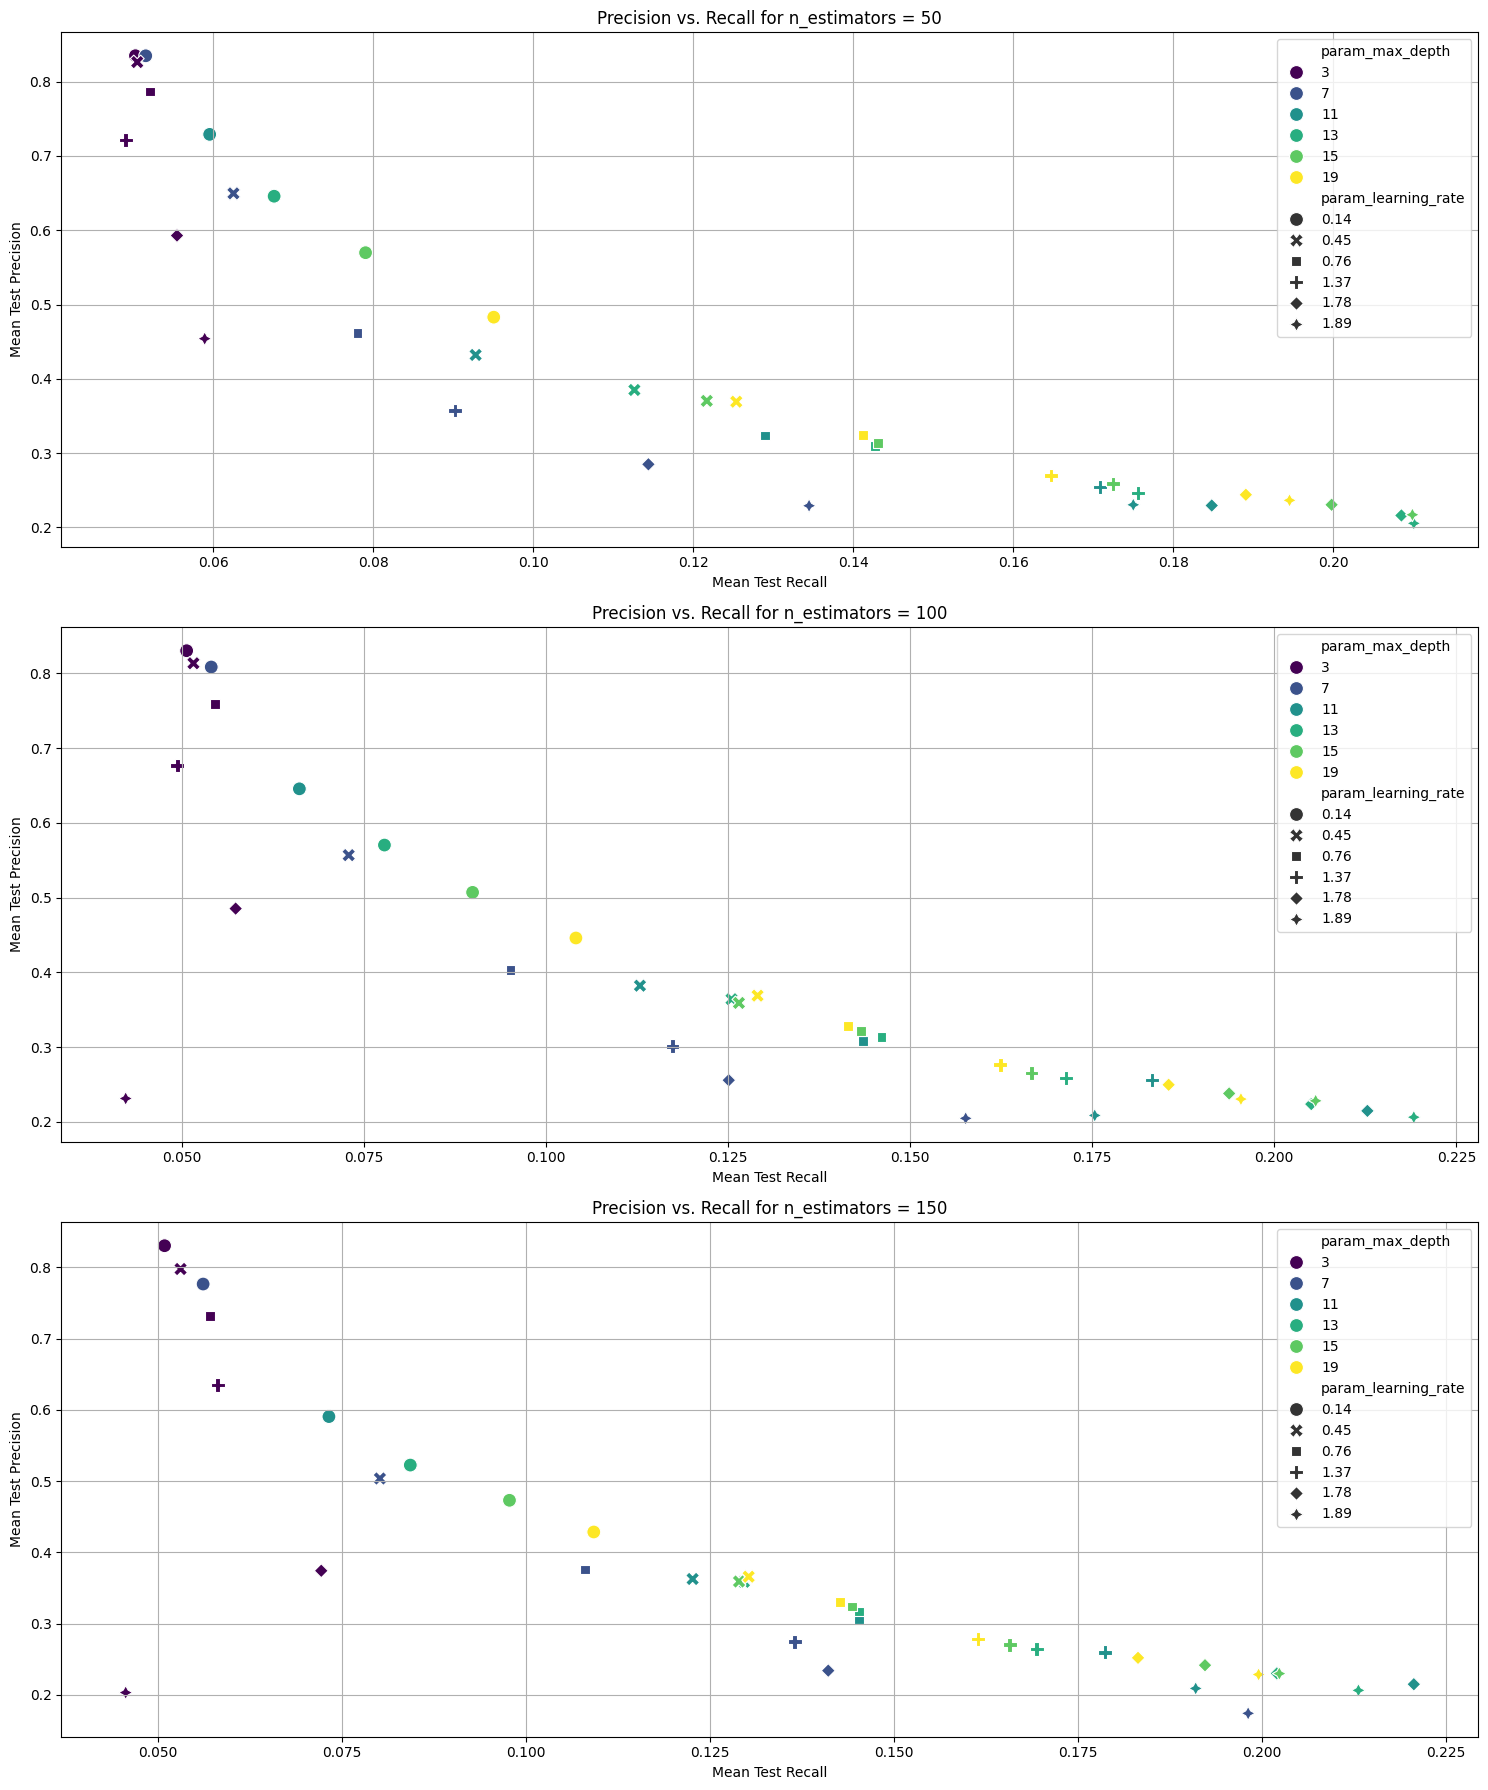

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming results_df is available from previous execution
# results_df = pd.DataFrame(grid_search.cv_results_)

unique_n_estimators = results_df['param_n_estimators'].unique()

plt.figure(figsize=(15, 6 * len(unique_n_estimators))) # Adjust figure size dynamically

for i, n_est in enumerate(sorted(unique_n_estimators)):
    subset_df = results_df[results_df['param_n_estimators'] == n_est].copy() # .copy() to avoid SettingWithCopyWarning

    plt.subplot(len(unique_n_estimators), 1, i + 1)
    sns.scatterplot(
        data=subset_df,
        x='mean_test_recall',
        y='mean_test_precision',
        hue='param_max_depth',
        style='param_learning_rate',
        s=100, # size of points
        palette='viridis',
    )
    plt.title(f'Precision vs. Recall for n_estimators = {n_est}')
    plt.xlabel('Mean Test Recall')
    plt.ylabel('Mean Test Precision')
    plt.grid(True)

plt.tight_layout()
plt.show()

Top 10 Most Important Features:


,Feature,Importance
169,group_noshow_count,0.032043
200,c5_ED_stt_Moderate,0.030623
154,z_ED_nat,0.023098
191,c5_SE_nat_Low,0.022823
4,NOSHOWS_365,0.021497
142,EP_HISP,0.021157
79,SPL_THEME1,0.017609
60,EP_LIMENG,0.017540
187,c5_HE_nat_Low,0.014534
28,E_LIMENG,0.014255


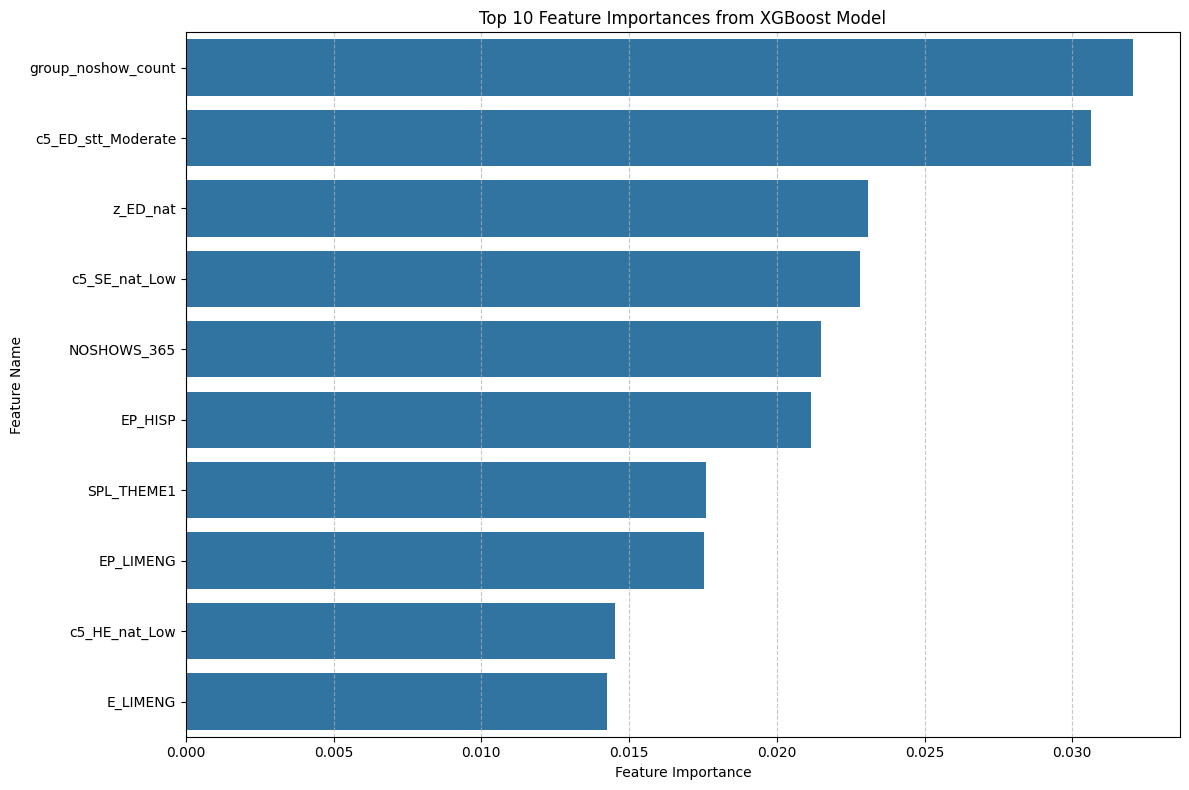

In [ ]:
# @title
# Get feature importances from the best XGBoost model
feature_importances = best_model.feature_importances_

# Get feature names from the numerical dataframe
feature_names = X_processed.columns

# Create a DataFrame for better visualization and sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
display(importance_df.head(10))

# Plot the top N most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances from XGBoost Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Training XGBoost model with best precision parameters...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:33:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete.


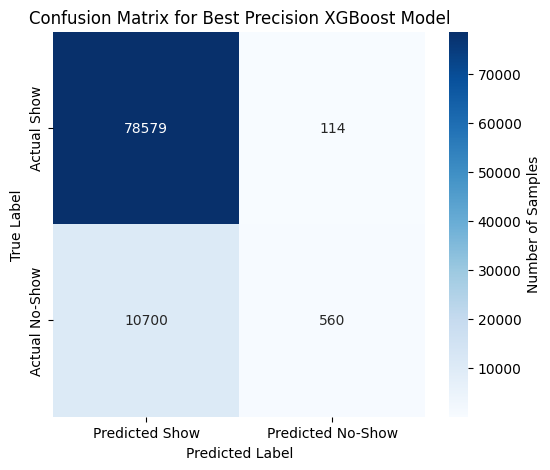

Precision score of the model with highest precision parameters on the test set: 0.8309
Recall score of the model with highest precision parameters on the test set: 0.0497
F1 score of the model with highest precision parameters on the test set: 0.0938


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. Retrieve the best parameters for precision
results_df = pd.DataFrame(grid_search.cv_results_)
best_precision_index = results_df['mean_test_precision'].idxmax()
best_precision_params = results_df.loc[best_precision_index][['param_n_estimators', 'param_max_depth', 'param_learning_rate']]

best_n_estimators_precision = int(best_precision_params['param_n_estimators'])
best_max_depth_precision = int(best_precision_params['param_max_depth'])
best_learning_rate_precision = float(best_precision_params['param_learning_rate'])

# 2. Instantiate and train a new XGBoost model with these parameters
best_precision_xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=best_n_estimators_precision,
    max_depth=best_max_depth_precision,
    learning_rate=best_learning_rate_precision
)

print("Training XGBoost model with best precision parameters...")
best_precision_xgb_model.fit(X_tune_train, y_tune_train)
print("Training complete.")

# 3. Make predictions on the test set
y_pred_precision_model = best_precision_xgb_model.predict(X_tune_test)

# 4. Compute the confusion matrix
cm_precision_model = confusion_matrix(y_tune_test, y_pred_precision_model)

# 5. Plot the confusion matrix
plt.figure(figsize=(6, 5)) # Made figure size smaller
sns.heatmap(cm_precision_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Show', 'Predicted No-Show'], # Updated labels
            yticklabels=['Actual Show', 'Actual No-Show'], # Updated labels
            cbar_kws={'label': 'Number of Samples'}) # Added color axis title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Precision XGBoost Model')
plt.show()

# Print precision, recall, and F1-score for verification on the test set
precision_of_best_precision_model = precision_score(y_tune_test, y_pred_precision_model)
recall_of_best_precision_model = recall_score(y_tune_test, y_pred_precision_model)
f1_of_best_precision_model = f1_score(y_tune_test, y_pred_precision_model)

print(f"Precision score of the model with highest precision parameters on the test set: {precision_of_best_precision_model:.4f}")
print(f"Recall score of the model with highest precision parameters on the test set: {recall_of_best_precision_model:.4f}")
print(f"F1 score of the model with highest precision parameters on the test set: {f1_of_best_precision_model:.4f}")

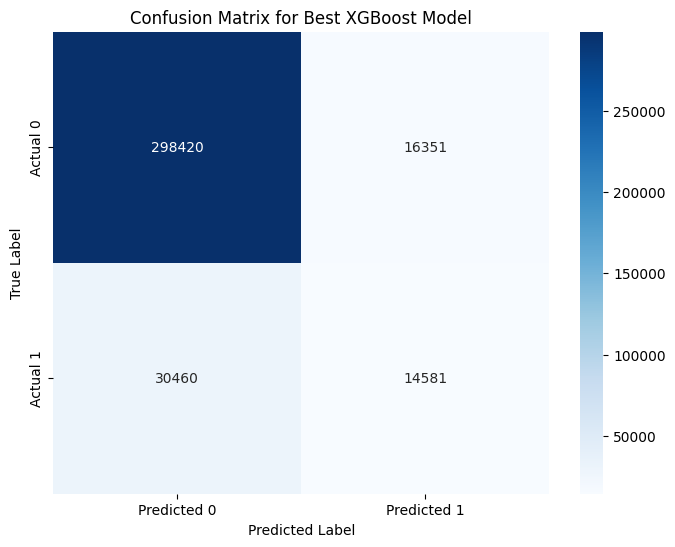

In [ ]:
# Assuming best_model, X_tune_test, and y_tune_test are already defined from previous cells
# Make predictions on the test set
y_pred = best_model.predict(X_tune_train)

# Compute the confusion matrix
cm = confusion_matrix(y_tune_train, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best XGBoost Model')
plt.show()